# Chapter 12: Applications of the Homogeneous Model

This notebook is a standalone, executable reconstruction of the ideas in Chapter 12, **Applications of the Homogeneous Model**, aligned with the book's printed pages 327-354. The page audit was made from the local PDF before authoring this notebook. The verified headings in that span are: homogeneous Plucker coordinates in 3-D; line representation; coordinate forms of points, planes, and lines; combining elements; motion matrices for Plucker coordinates; sparse use of the coordinate algebra; imaging by multiple cameras; the pinhole camera; homogeneous coordinates as imaging; cameras and stereo vision; line-based stereo vision; further reading; exercises; OpenGL transformation examples; transforming primitives with OpenGL matrices; marker reconstruction in optical motion capture; and the crossing-lines code that closes printed page 354.

The notebook keeps the exposition original and computational. The chapter's main claim is practical: the homogeneous model is not only a way to draw projective pictures. It gives a uniform language for offset flats, camera rays, epipolar geometry, and the matrix conventions used in graphics systems. In a conventional linear algebra course these topics often look like separate toolboxes: six Plucker line numbers here, camera matrices there, OpenGL transforms somewhere else. Homogeneous geometric algebra explains why they are versions of the same habit. A point becomes a vector in a larger space, a line becomes the outer product of two points, a plane becomes a covector or dual blade, and incidence is tested by contraction, wedge, meet, or the coordinate formulas that those products induce.

The chapter also has a useful boundary. Homogeneous coordinates excel at incidence and projective relationships, while metric measurements need care. Depth from two cameras, closest points on skew rays, and marker reconstruction all require numerical choices once observations are noisy. That is why the notebook alternates between algebraic invariants and least-squares computations. The algebra tells us what should be zero in exact geometry; the numerical code tells us how far from zero a measured scene has drifted.


## Reading Map And Source Audit

Printed pages 327-354 begin with the chapter opening and continue through the programming example for closest points on crossing lines. The headings are worth verifying because they reveal the chapter's architecture. Section 12.1 builds the coordinate bridge: a 3-D line is represented as a homogeneous 2-blade, whose six coordinates can be grouped as a direction and a moment. Those are the Plucker coordinates. Section 12.2 moves to cameras: a pinhole camera turns a world point into a ray-plane incidence problem, and a pair of cameras produces the epipolar constraint. Section 12.5 then grounds the same machinery in code-level graphics tasks: loading transformations into OpenGL, transforming primitives by 4-by-4 matrices, reconstructing motion-capture markers, and computing closest points on crossing lines.

This notebook uses the following naming convention. A homogeneous 3-D point is written as a four-vector `[x, y, z, w]`; a finite point has `w != 0` and can be divided by `w`. A Plucker line is stored as `(d, m)`, where `d` is the oriented direction and `m = p x d` is the moment of the line about the origin. Some texts use the negative of this direction in their coordinate table. That sign convention is harmless if it is used consistently, but for programming it is easier to use the direction a ray or line actually travels. A pinhole camera stores a center, a world-to-camera rotation, and a focal length. Image points are homogeneous 2-D coordinates `[u, v, 1]`, so image lines are three-vectors `[a, b, c]` with equation `a*u + b*v + c = 0`.

The code intentionally stays explicit. A professional vision or graphics stack would hide many operations behind optimized kernels, but the purpose here is to keep the transformations inspectable. Each section writes an artifact so the notebook leaves evidence of what was checked: JSON summaries for invariants, PNG figures for geometry, and a final sanity report.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

BOOK_ROOT = Path.cwd()
for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils" / "chapter12_homogeneous_applications.py").exists():
        BOOK_ROOT = candidate
        break

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import display_artifact, save_json, save_matplotlib
from utils.chapter12_homogeneous_applications import (
    closest_points_on_lines,
    epipolar_residual,
    fundamental_matrix,
    homogeneous_point,
    make_camera,
    plucker_from_points,
    plucker_side,
    point_on_plucker,
    reconstruct_from_rays,
    rotation_z_matrix,
    transform_points,
    translation_matrix,
    view_matrix,
)

np.set_printoptions(precision=5, suppress=True)
ARTIFACT_ROOT = BOOK_ROOT / "artifacts"
ARTIFACT_TOPIC = "chapter-12"
print(f"Project root: {BOOK_ROOT}")
print(f"Artifact root: {ARTIFACT_ROOT / ARTIFACT_TOPIC}")


Project root: D:\Geometry\Geometric-Algebra-for-Computer-Science
Artifact root: D:\Geometry\Geometric-Algebra-for-Computer-Science\artifacts\chapter-12


In [2]:
PDF_AUDIT = {
    "source_pdf": "Geometric Algebra for Computer Science.pdf",
    "printed_page_span": "327-354",
    "physical_pdf_pages": "354-381",
    "verified_headings": [
        "12 Applications of the Homogeneous Model",
        "12.1 Homogeneous Plucker Coordinates in 3-D",
        "12.1.1 Line Representation",
        "12.1.2 The Elements in Coordinate Form",
        "12.1.3 Combining Elements",
        "12.1.4 Matrices of Motions in Plucker Coordinates",
        "12.1.5 Sparse Usage of the 24 Dimensions",
        "12.2 Imaging by Multiple Cameras",
        "12.2.1 The Pinhole Camera",
        "12.2.2 Homogeneous Coordinates as Imaging",
        "12.2.3 Cameras and Stereo Vision",
        "12.2.4 Line-Based Stereo Vision",
        "12.3 Further Reading",
        "12.4 Exercises",
        "12.4.1 Structural Exercises",
        "12.5 Programming Examples and Exercises",
        "12.5.1 Loading Transformations into OpenGL",
        "12.5.2 Transforming Primitives with OpenGL Matrices",
        "12.5.3 Marker Reconstruction in Optical Motion Capture",
        "Figure 12.8 Crossing Lines Code",
    ],
}
heading_audit_path = save_json(
    PDF_AUDIT, ARTIFACT_TOPIC, "pdf-probe", "heading-audit.json", root=ARTIFACT_ROOT
)
print(f"wrote {heading_audit_path}")


wrote D:\Geometry\Geometric-Algebra-for-Computer-Science\artifacts\chapter-12\pdf-probe\heading-audit.json


## Homogeneous Plucker Coordinates

A Euclidean point by itself is not enough to describe a free line in 3-D. The line needs an attitude and an offset. In the homogeneous model, two finite points become homogeneous vectors, and the line through them is their outer product. If the points have affine locations `p` and `q`, the line blade splits into a part that contains the direction `q - p` and a part that contains the moment `p x q`, or equivalently `p x (q - p)`. This is the coordinate grouping that classical Plucker coordinates store.

The moment is not a mysterious second direction. It records how the line misses the origin. If the same line is represented by another point `p + t*d`, then `(p + t*d) x d = p x d`, because `d x d = 0`. That invariance is the first sanity check for any Plucker implementation. The second is the Grassmann-Plucker constraint `d dot m = 0`: the direction is always perpendicular to the moment. The six numbers therefore carry only five independent degrees of freedom, matching the dimension of the set of oriented lines in 3-D.

The reciprocal product between two lines also has geometric meaning. For two exact coplanar lines, including intersecting lines, `d1 dot m2 + d2 dot m1` is zero. For skew lines this value is proportional to the signed volume swept by their directions and separation. A small nonzero value is often a better diagnostic than a Boolean test, because real measurements rarely satisfy exact incidence.


In [3]:
p = np.array([0.5, -0.2, 0.3])
q = np.array([3.0, 1.1, 1.6])
r = p + 0.75 * (q - p)
line_pq = plucker_from_points(p, q)
line_rq = plucker_from_points(r, q)
line_pq_unit = line_pq.normalized()
nearest_to_origin = point_on_plucker(line_pq)

plucker_report = {
    "direction": line_pq.direction.tolist(),
    "moment": line_pq.moment.tolist(),
    "grassmann_plucker_constraint": line_pq.constraint(),
    "same_line_moment_delta_norm": float(
        np.linalg.norm(line_pq.normalized().moment - line_rq.normalized().moment)
    ),
    "nearest_point_to_origin": nearest_to_origin.tolist(),
    "nearest_point_dot_direction": float(np.dot(nearest_to_origin, line_pq.direction)),
}
plucker_path = save_json(
    plucker_report, ARTIFACT_TOPIC, "checks", "plucker-line-invariants.json", root=ARTIFACT_ROOT
)
print(plucker_report)
print(f"wrote {plucker_path}")


{'direction': [2.5, 1.3, 1.3], 'moment': [-0.65, 0.09999999999999998, 1.15], 'grassmann_plucker_constraint': -2.220446049250313e-16, 'same_line_moment_delta_norm': 4.2914688736145975e-16, 'nearest_point_to_origin': [-0.14174454828660435, 0.3862928348909657, -0.11370716510903425], 'nearest_point_dot_direction': 5.551115123125783e-17}
wrote D:\Geometry\Geometric-Algebra-for-Computer-Science\artifacts\chapter-12\checks\plucker-line-invariants.json


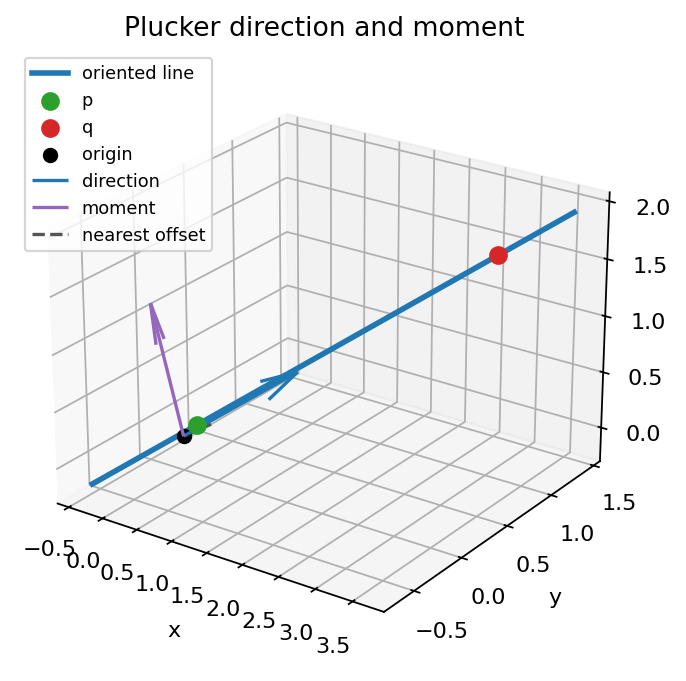

In [4]:
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection="3d")
line_t = np.linspace(-0.35, 1.25, 30)
line_points = p[None, :] + line_t[:, None] * (q - p)[None, :]
ax.plot(line_points[:, 0], line_points[:, 1], line_points[:, 2], color="#1f77b4", linewidth=2.5, label="oriented line")
ax.scatter(*p, color="#2ca02c", s=55, label="p")
ax.scatter(*q, color="#d62728", s=55, label="q")
ax.scatter(0, 0, 0, color="black", s=35, label="origin")
ax.quiver(0, 0, 0, *line_pq_unit.direction, length=1.2, color="#1f77b4", normalize=True, label="direction")
ax.quiver(0, 0, 0, *line_pq_unit.moment, length=1.2, color="#9467bd", normalize=True, label="moment")
ax.plot([0, nearest_to_origin[0]], [0, nearest_to_origin[1]], [0, nearest_to_origin[2]], color="#555555", linestyle="--", label="nearest offset")
ax.set_title("Plucker direction and moment")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend(loc="upper left", fontsize=8)
ax.view_init(elev=24, azim=-55)
plucker_fig_path = save_matplotlib(
    fig, ARTIFACT_TOPIC, "figures", "plucker-direction-moment.png", root=ARTIFACT_ROOT
)
plt.close(fig)
display_artifact(plucker_fig_path, width=640)


## Coordinate Forms And Combining Elements

The homogeneous model has two complementary attitudes toward coordinates. One attitude says that a line is a blade and that products should be written geometrically. The other says that software stores arrays, so we need a reliable ordering of those arrays. Plucker coordinates are the meeting point of those attitudes. They are coordinates of a line blade, but they keep enough structure that line formulas can be derived instead of memorized.

For example, a line-plane incidence test can be interpreted as substituting every point on the line into the plane equation. If a plane has equation `n dot x - delta = 0` and a line is `x(t) = p + t*d`, the line lies in the plane exactly when `n dot d = 0` and `n dot p - delta = 0`. In blade language that is the statement that joining the line with the plane produces no volume. In a coordinate table it becomes a few dot products. These are not competing methods; the table is the coordinate shadow of the algebra.

Combining two Plucker lines also shows why the homogeneous model is useful in programming. A pair of lines can intersect, be parallel, be coincident, or be skew. Instead of beginning with case distinctions, compute the invariant that should vanish for coplanarity and then compute closest points if the invariant says they miss. This is the same design pattern used later in the motion-capture example: let incidence guide the data association, and let least squares absorb measurement noise.


In [5]:
line_a = plucker_from_points([0.0, 0.0, 0.0], [2.0, 1.0, 0.4])
line_b = plucker_from_points([0.5, -1.0, 0.7], [0.7, 1.4, 2.0])
line_c = plucker_from_points([0.0, 0.0, 0.0], [0.7, 1.4, 2.0])

closest_ab = closest_points_on_lines(
    point_on_plucker(line_a), line_a.direction,
    point_on_plucker(line_b), line_b.direction,
)
combining_report = {
    "skew_line_side_value": plucker_side(line_a, line_b),
    "intersecting_line_side_value": plucker_side(line_a, line_c),
    "closest_distance_for_skew_pair": closest_ab["distance"],
    "closest_point_on_a": closest_ab["point1"].tolist(),
    "closest_point_on_b": closest_ab["point2"].tolist(),
}
combining_path = save_json(
    combining_report, ARTIFACT_TOPIC, "checks", "line-combination-report.json", root=ARTIFACT_ROOT
)
print(combining_report)
print(f"wrote {combining_path}")


{'skew_line_side_value': -5.91, 'intersecting_line_side_value': 0.0, 'closest_distance_for_skew_pair': 1.1244197808761502, 'closest_point_on_a': [-0.4859190617534207, -0.24295953087671035, -0.09718381235068416], 'closest_point_on_b': [-0.5586548903207122, 0.2961413161514515, -1.0812567870846304]}
wrote D:\Geometry\Geometric-Algebra-for-Computer-Science\artifacts\chapter-12\checks\line-combination-report.json


## Pinhole Camera Geometry

A pinhole camera is a controlled loss of dimension. Every visible world point, the camera center, and the image point lie on one ray. In homogeneous coordinates the image point is not a metric point on the sensor as much as it is a representative of the whole ray. Multiplying it by a nonzero scalar changes the representative, not the ray. That is exactly the same equivalence relation used for projective points.

This is why the homogeneous model is natural for camera geometry. Projection is a linear map from homogeneous world coordinates to homogeneous image coordinates, followed by the usual division by the last coordinate when an affine image coordinate is needed. The pinhole center is the null space of that map. A 3-D line projects to a 2-D image line unless it passes through the center, and an image line back-projects to a plane of rays through the center. These facts sound different in a graphics API, a computer-vision paper, and a geometric algebra text, but they are the same incidence statement.

The next cells create a small world scene and two calibrated cameras. We project a set of markers and line endpoints, then save both numeric observations and image-space figures. The cameras use a positive local `z` axis as their viewing direction, which keeps the formulas readable: divide by camera `z`, multiply by focal length, and append the homogeneous coordinate `1`.


In [6]:
world_points = np.array([
    [-0.8, -0.5, 0.1],
    [0.6, -0.4, 0.2],
    [0.9, 0.6, -0.1],
    [-0.5, 0.7, 0.15],
    [0.2, 0.1, 0.9],
])
line_segment = np.array([[-0.75, 0.25, -0.15], [0.85, 0.55, 0.35]])
left_camera = make_camera("left", center=[-2.6, 0.2, 1.25], target=[0.0, 0.0, 0.2], focal_length=1.35)
right_camera = make_camera("right", center=[2.4, 0.15, 1.15], target=[0.0, 0.0, 0.2], focal_length=1.35)
cameras = [left_camera, right_camera]

image_observations = {
    cam.name: np.array([cam.project(point) for point in world_points])
    for cam in cameras
}
line_observations = {
    cam.name: np.array([cam.project(point) for point in line_segment])
    for cam in cameras
}
projection_report = {
    "world_points": world_points.tolist(),
    "line_segment": line_segment.tolist(),
    "image_points": {name: pts.tolist() for name, pts in image_observations.items()},
    "line_endpoint_images": {name: pts.tolist() for name, pts in line_observations.items()},
    "left_projection_matrix": left_camera.matrix.tolist(),
    "right_projection_matrix": right_camera.matrix.tolist(),
}
projection_path = save_json(
    projection_report, ARTIFACT_TOPIC, "camera", "pinhole-observations.json", root=ARTIFACT_ROOT
)
print(f"wrote {projection_path}")
print(image_observations["left"][:2])


wrote D:\Geometry\Geometric-Algebra-for-Computer-Science\artifacts\chapter-12\camera\pinhole-observations.json
[[-0.247   -0.34556  1.     ]
 [ 0.08935 -0.14293  1.     ]]


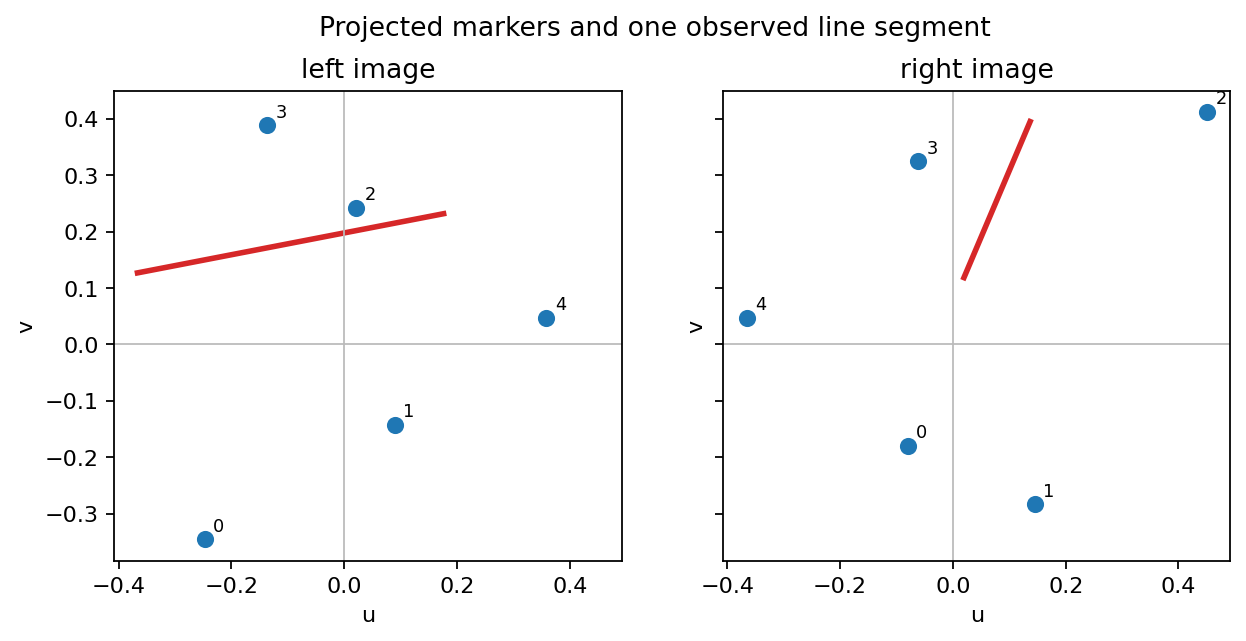

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharex=True, sharey=True)
for ax, cam in zip(axes, cameras):
    pts = image_observations[cam.name]
    seg = line_observations[cam.name]
    ax.scatter(pts[:, 0], pts[:, 1], color="#1f77b4", s=45)
    for idx, point in enumerate(pts):
        ax.text(point[0] + 0.015, point[1] + 0.015, str(idx), fontsize=8)
    ax.plot(seg[:, 0], seg[:, 1], color="#d62728", linewidth=2.5)
    ax.axhline(0, color="#bbbbbb", linewidth=0.8)
    ax.axvline(0, color="#bbbbbb", linewidth=0.8)
    ax.set_title(f"{cam.name} image")
    ax.set_xlabel("u")
    ax.set_ylabel("v")
    ax.set_aspect("equal", adjustable="box")
fig.suptitle("Projected markers and one observed line segment")
image_fig_path = save_matplotlib(
    fig, ARTIFACT_TOPIC, "figures", "pinhole-image-observations.png", root=ARTIFACT_ROOT
)
plt.close(fig)
display_artifact(image_fig_path, width=760)


## Epipolar Constraint

With two cameras, each image point in the left image determines a ray in space. The right camera center and that left ray span an epipolar plane. The matching point in the right image must lie on the image line where that plane cuts the right image plane. In homogeneous image coordinates this is the scalar equation `x_right^T F x_left = 0`, where `F` is the fundamental matrix. If the cameras are calibrated and normalized image coordinates are used, the same idea is expressed by the essential matrix.

The important modeling point is that the epipolar constraint is not a correlation rule or an image-processing trick. It is a projective incidence condition. It prunes the search for correspondences because geometry says the match cannot be anywhere else. When observations are noisy, the residual is no longer exactly zero, but it remains a signed distance-like diagnostic once the image line is normalized.

In the cell below the cameras are exact and the image points come from the same world markers, so the residuals should be close to floating-point zero. Then the notebook draws epipolar lines in the right image for the left observations. Each right marker should lie on the corresponding line. The figure is deliberately simple: it is the epipolar constraint as a visual debugging tool, which is often more useful than staring at a matrix.


In [8]:
F_lr = fundamental_matrix(left_camera, right_camera)
epipolar_residuals = [
    epipolar_residual(F_lr, image_observations["left"][i], image_observations["right"][i])
    for i in range(len(world_points))
]
epipolar_lines_right = np.array([F_lr @ x_left for x_left in image_observations["left"]])
epipolar_report = {
    "fundamental_matrix_left_to_right": F_lr.tolist(),
    "residuals": epipolar_residuals,
    "max_abs_residual": float(np.max(np.abs(epipolar_residuals))),
    "right_epipolar_lines": epipolar_lines_right.tolist(),
}
epipolar_path = save_json(
    epipolar_report, ARTIFACT_TOPIC, "checks", "epipolar-constraint.json", root=ARTIFACT_ROOT
)
print(f"max residual: {epipolar_report['max_abs_residual']:.3e}")
print(f"wrote {epipolar_path}")


max residual: 2.220e-16
wrote D:\Geometry\Geometric-Algebra-for-Computer-Science\artifacts\chapter-12\checks\epipolar-constraint.json


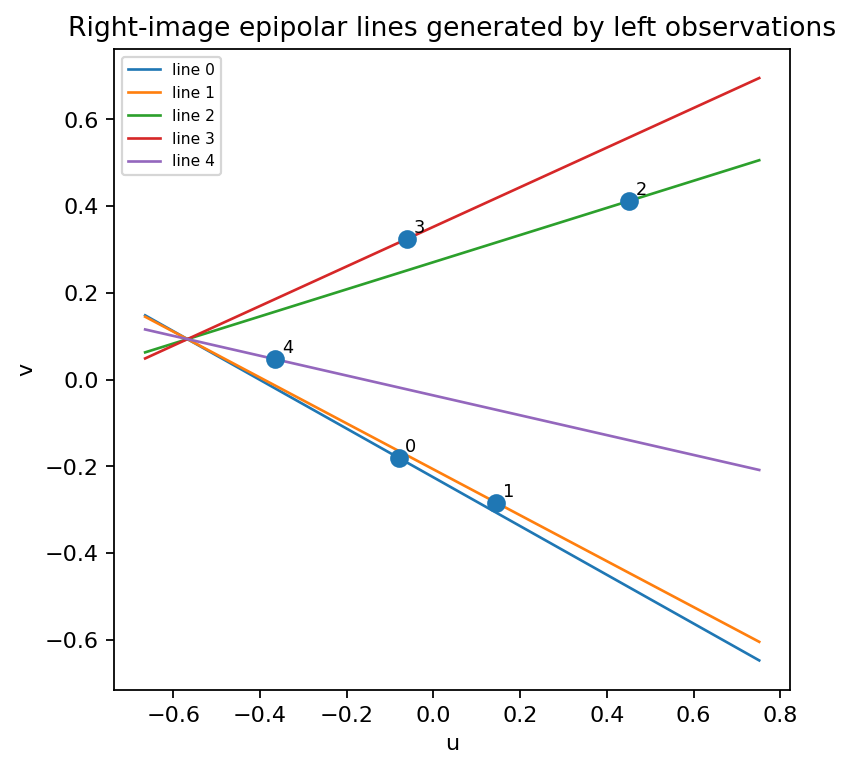

In [9]:
fig, ax = plt.subplots(figsize=(5.8, 5.2))
right_pts = image_observations["right"]
ax.scatter(right_pts[:, 0], right_pts[:, 1], color="#1f77b4", s=55, zorder=3)
for idx, (point, line) in enumerate(zip(right_pts, epipolar_lines_right)):
    a, b, c = line
    xs = np.linspace(right_pts[:, 0].min() - 0.3, right_pts[:, 0].max() + 0.3, 80)
    if abs(b) > 1e-12:
        ys = -(a * xs + c) / b
        ax.plot(xs, ys, linewidth=1.2, label=f"line {idx}")
    ax.text(point[0] + 0.015, point[1] + 0.015, str(idx), fontsize=8)
ax.set_title("Right-image epipolar lines generated by left observations")
ax.set_xlabel("u")
ax.set_ylabel("v")
ax.set_aspect("equal", adjustable="box")
ax.legend(fontsize=7, loc="best")
epipolar_fig_path = save_matplotlib(
    fig, ARTIFACT_TOPIC, "figures", "epipolar-lines.png", root=ARTIFACT_ROOT
)
plt.close(fig)
display_artifact(epipolar_fig_path, width=620)


## Ray Planes From Line Observations

Point stereo begins with a point in one image and asks where its mate can lie in another image. Line stereo begins with a line observed in an image. A 2-D image line does not identify one 3-D line by itself. Instead it identifies a plane of rays: every world point whose image lies on that image line is somewhere in the plane through the camera center and the observed line on the image plane.

Two cameras observing the same world line therefore give two ray planes. Their intersection is the reconstructed 3-D line. This is a direct homogeneous-model move: an image line is a dual object in the image plane, its back-projection is a plane in world space, and the meet of two planes is a line. In exact arithmetic, the recovered line contains both original endpoints. In measured data, the two planes may be slightly inconsistent, so the reconstructed line is usually estimated together with a confidence measure.

The next cell takes the projected line segment from the previous scene, computes each image line as the cross product of the two projected endpoints, back-projects those image lines into world ray planes, and intersects the planes. The line direction is the cross product of the plane normals. A point on the line is found by solving the two plane equations in the least-norm sense, which gives the point nearest the origin among all points satisfying both plane constraints.


In [10]:
def image_line_from_points(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    line = np.cross(a, b)
    return line / np.linalg.norm(line[:2])


image_lines = {
    cam.name: image_line_from_points(*line_observations[cam.name])
    for cam in cameras
}
ray_planes = {
    cam.name: cam.ray_plane_from_image_line(image_lines[cam.name])
    for cam in cameras
}
n1, delta1 = ray_planes["left"]
n2, delta2 = ray_planes["right"]
reconstructed_direction = np.cross(n1, n2)
plane_system = np.vstack([n1, n2, reconstructed_direction])
plane_rhs = np.array([delta1, delta2, 0.0])
reconstructed_point = np.linalg.solve(plane_system, plane_rhs)
reconstructed_line = plucker_from_points(reconstructed_point, reconstructed_point + reconstructed_direction)
original_line = plucker_from_points(line_segment[0], line_segment[1])
line_alignment = abs(np.dot(reconstructed_line.normalized().direction, original_line.normalized().direction))
endpoint_plane_residuals = [
    [float(np.dot(normal, endpoint) - delta) for normal, delta in ray_planes.values()]
    for endpoint in line_segment
]
ray_plane_report = {
    "image_lines": {name: line.tolist() for name, line in image_lines.items()},
    "ray_planes": {
        name: {"normal": normal.tolist(), "offset": offset}
        for name, (normal, offset) in ray_planes.items()
    },
    "reconstructed_point_on_line": reconstructed_point.tolist(),
    "reconstructed_direction": reconstructed_direction.tolist(),
    "absolute_direction_alignment_with_original": float(line_alignment),
    "endpoint_plane_residuals": endpoint_plane_residuals,
}
ray_plane_path = save_json(
    ray_plane_report, ARTIFACT_TOPIC, "checks", "ray-planes-from-line-observations.json", root=ARTIFACT_ROOT
)
print(f"direction alignment: {line_alignment:.6f}")
print(f"wrote {ray_plane_path}")


direction alignment: 1.000000
wrote D:\Geometry\Geometric-Algebra-for-Computer-Science\artifacts\chapter-12\checks\ray-planes-from-line-observations.json


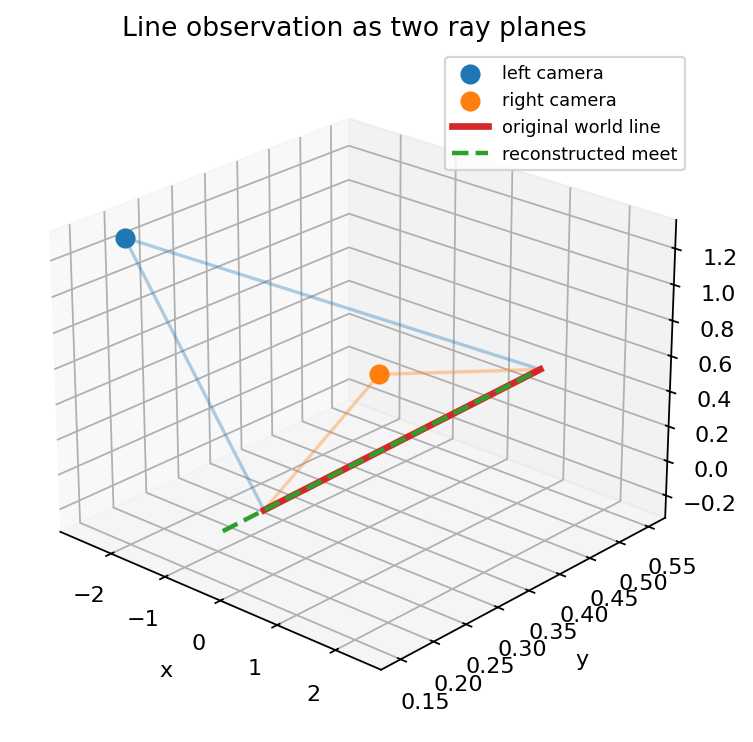

In [11]:
fig = plt.figure(figsize=(7, 5.5))
ax = fig.add_subplot(111, projection="3d")
colors = {"left": "#1f77b4", "right": "#ff7f0e"}
for cam in cameras:
    ax.scatter(*cam.center, color=colors[cam.name], s=65, label=f"{cam.name} camera")
    for endpoint in line_segment:
        ax.plot([cam.center[0], endpoint[0]], [cam.center[1], endpoint[1]], [cam.center[2], endpoint[2]], color=colors[cam.name], alpha=0.35)
ax.plot(line_segment[:, 0], line_segment[:, 1], line_segment[:, 2], color="#d62728", linewidth=3, label="original world line")
t = np.linspace(-1.0, 1.0, 20)
rec_pts = reconstructed_point[None, :] + t[:, None] * reconstructed_direction[None, :]
ax.plot(rec_pts[:, 0], rec_pts[:, 1], rec_pts[:, 2], color="#2ca02c", linestyle="--", linewidth=2, label="reconstructed meet")
ax.set_title("Line observation as two ray planes")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend(fontsize=8)
ax.view_init(elev=24, azim=-48)
ray_plane_fig_path = save_matplotlib(
    fig, ARTIFACT_TOPIC, "figures", "line-ray-planes.png", root=ARTIFACT_ROOT
)
plt.close(fig)
display_artifact(ray_plane_fig_path, width=660)


## Motion-Capture Reconstruction

Optical motion capture is a natural application for homogeneous camera geometry because each bright marker generates many camera rays. The ideal reconstruction is the point where all corresponding rays meet. Real systems must first decide which observations belong to the same marker, then estimate a point that is close to all selected rays. The homogeneous model helps organize both phases. Epipolar geometry narrows candidate matches between camera pairs, and ray intersection or least squares turns accepted matches into 3-D points.

The code below simulates three cameras looking at several markers. It adds a tiny deterministic image perturbation so the rays do not meet perfectly. Each marker is reconstructed from all three rays by solving a least-squares point-to-lines problem. The residual is the root mean square distance from the reconstructed point to the rays. In a real marker pipeline, this residual would become part of the quality gate for accepting or rejecting a candidate cluster.

Notice that the algorithm does not need to know the marker's depth in any one camera. Depth is an outcome of intersecting projective information. This is one of the reasons homogeneous coordinates remain so durable in vision systems: they postpone division and metric interpretation until the incidence constraints have done as much work as possible.


In [12]:
third_camera = make_camera("top", center=[0.1, 2.8, 2.4], target=[0.0, 0.0, 0.2], focal_length=1.25)
mocap_cameras = [left_camera, right_camera, third_camera]
noise_pattern = np.array([[0.0012, -0.0007, 0.0], [-0.0008, 0.0010, 0.0], [0.0005, 0.0009, 0.0]])
reconstructions = []
for marker_index, marker in enumerate(world_points):
    rays = []
    noisy_images = []
    for cam_index, cam in enumerate(mocap_cameras):
        image_point = cam.project(marker) + noise_pattern[(marker_index + cam_index) % len(noise_pattern)]
        image_point = image_point / image_point[2]
        noisy_images.append(image_point)
        rays.append(cam.ray_from_image(image_point))
    reconstruction = reconstruct_from_rays(rays)
    reconstructions.append({
        "marker_index": marker_index,
        "truth": marker.tolist(),
        "estimate": reconstruction["point"].tolist(),
        "error": float(np.linalg.norm(reconstruction["point"] - marker)),
        "rms_ray_residual": reconstruction["rms"],
        "noisy_images": [point.tolist() for point in noisy_images],
    })

mocap_report = {
    "camera_names": [cam.name for cam in mocap_cameras],
    "max_position_error": max(item["error"] for item in reconstructions),
    "mean_position_error": float(np.mean([item["error"] for item in reconstructions])),
    "reconstructions": reconstructions,
}
mocap_path = save_json(
    mocap_report, ARTIFACT_TOPIC, "checks", "motion-capture-reconstruction.json", root=ARTIFACT_ROOT
)
print(f"max reconstruction error: {mocap_report['max_position_error']:.5f}")
print(f"wrote {mocap_path}")


max reconstruction error: 0.00300
wrote D:\Geometry\Geometric-Algebra-for-Computer-Science\artifacts\chapter-12\checks\motion-capture-reconstruction.json


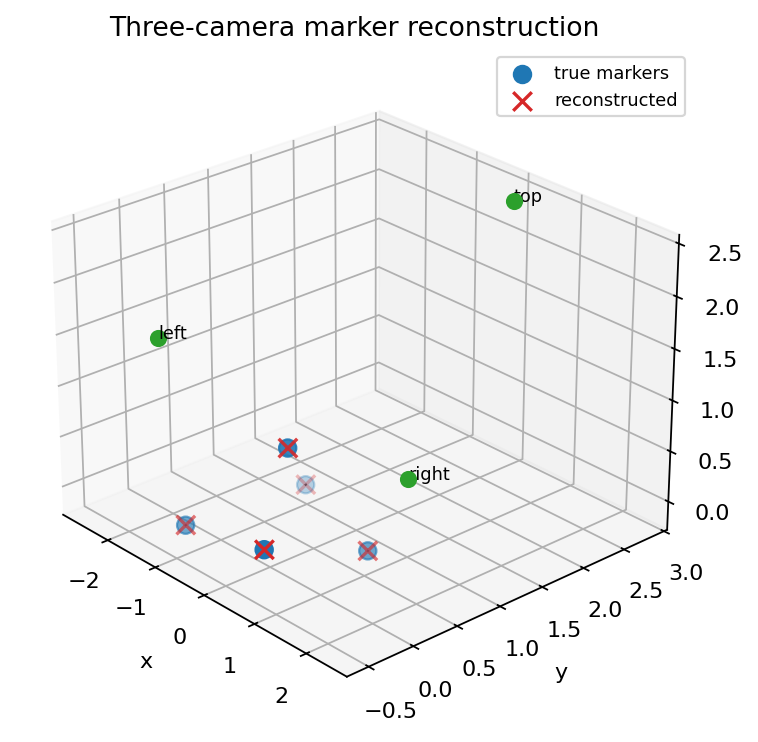

In [13]:
fig = plt.figure(figsize=(7, 5.5))
ax = fig.add_subplot(111, projection="3d")
truth = world_points
estimate = np.array([item["estimate"] for item in reconstructions])
ax.scatter(truth[:, 0], truth[:, 1], truth[:, 2], color="#1f77b4", s=60, label="true markers")
ax.scatter(estimate[:, 0], estimate[:, 1], estimate[:, 2], color="#d62728", marker="x", s=70, label="reconstructed")
for a, b in zip(truth, estimate):
    ax.plot([a[0], b[0]], [a[1], b[1]], [a[2], b[2]], color="#555555", linewidth=1)
for cam in mocap_cameras:
    ax.scatter(*cam.center, color="#2ca02c", s=45)
    ax.text(*cam.center, cam.name, fontsize=8)
ax.set_title("Three-camera marker reconstruction")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend(fontsize=8)
ax.view_init(elev=26, azim=-42)
mocap_fig_path = save_matplotlib(
    fig, ARTIFACT_TOPIC, "figures", "motion-capture-reconstruction.png", root=ARTIFACT_ROOT
)
plt.close(fig)
display_artifact(mocap_fig_path, width=660)


## OpenGL-Style Homogeneous Transforms

The programming examples in the printed span emphasize interoperability with graphics-style homogeneous matrices. A 4-by-4 matrix can translate, rotate, scale, shear, and project finite points because the extra coordinate turns affine operations into linear ones. For direct points, the matrix acts by ordinary multiplication. For dual planes, the inverse-transpose appears. For lines, one may transform the two endpoint points and rebuild the line, or use the induced outermorphism on the line blade.

OpenGL conventions historically add one more source of confusion: row-major versus column-major storage, object-to-world versus world-to-camera direction, and camera transforms described as moving the camera versus moving the world. The homogeneous model does not remove the need to track conventions, but it gives a compact invariant to test them. If a point lies on a plane before transformation, the transformed point must lie on the transformed plane. If two points lie on a line before transformation, their transformed points define the transformed line. If a view matrix is meant to put the camera center at the origin, multiplying the camera center by the view matrix should return `[0, 0, 0, 1]`.

The next cell builds a small cube-like primitive, applies an object transform, and then applies a camera view transform. The JSON artifact records the matrices and a few convention checks. The figure shows the object in world coordinates and in camera coordinates, reinforcing that a matrix is not just a bag of numbers. It is a mapping between frames.


In [14]:
cube_points = np.array([
    [-0.4, -0.4, -0.4], [0.4, -0.4, -0.4], [0.4, 0.4, -0.4], [-0.4, 0.4, -0.4],
    [-0.4, -0.4, 0.4], [0.4, -0.4, 0.4], [0.4, 0.4, 0.4], [-0.4, 0.4, 0.4],
])
object_matrix = translation_matrix([0.15, -0.25, 0.35]) @ rotation_z_matrix(np.deg2rad(28.0))
world_cube = transform_points(object_matrix, cube_points)
left_view = view_matrix(left_camera)
camera_cube = transform_points(left_view, world_cube)
left_center_in_view = left_view @ homogeneous_point(left_camera.center)
transform_report = {
    "object_matrix": object_matrix.tolist(),
    "left_view_matrix": left_view.tolist(),
    "camera_center_after_view_transform": left_center_in_view.tolist(),
    "world_cube_centroid": world_cube.mean(axis=0).tolist(),
    "camera_cube_z_range": [float(camera_cube[:, 2].min()), float(camera_cube[:, 2].max())],
}
transform_path = save_json(
    transform_report, ARTIFACT_TOPIC, "checks", "opengl-style-transforms.json", root=ARTIFACT_ROOT
)
print(f"camera center in view coordinates: {left_center_in_view}")
print(f"wrote {transform_path}")


camera center in view coordinates: [ 0. -0. -0.  1.]
wrote D:\Geometry\Geometric-Algebra-for-Computer-Science\artifacts\chapter-12\checks\opengl-style-transforms.json


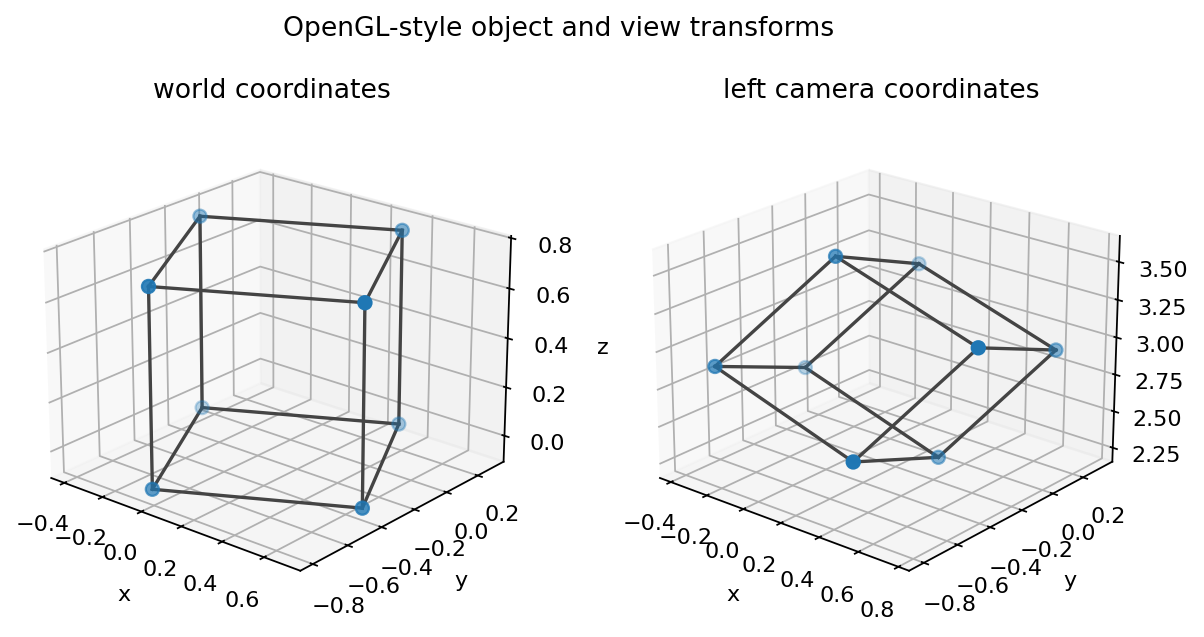

In [15]:
edges = [(0, 1), (1, 2), (2, 3), (3, 0), (4, 5), (5, 6), (6, 7), (7, 4), (0, 4), (1, 5), (2, 6), (3, 7)]
fig = plt.figure(figsize=(9, 4.5))
for subplot, points, title in [(121, world_cube, "world coordinates"), (122, camera_cube, "left camera coordinates")]:
    ax = fig.add_subplot(subplot, projection="3d")
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], color="#1f77b4", s=35)
    for i, j in edges:
        ax.plot([points[i, 0], points[j, 0]], [points[i, 1], points[j, 1]], [points[i, 2], points[j, 2]], color="#444444")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.view_init(elev=22, azim=-50)
fig.suptitle("OpenGL-style object and view transforms")
transform_fig_path = save_matplotlib(
    fig, ARTIFACT_TOPIC, "figures", "opengl-style-transforms.png", root=ARTIFACT_ROOT
)
plt.close(fig)
display_artifact(transform_fig_path, width=760)


## Crossing-Line Programming Lab

The crossing-line code at the end of the printed page span computes the closest points on two nonparallel lines. This is a small routine, but it condenses several chapter themes. A line is passed in factored form as a point and a direction. The directions span a bivector plane unless they are parallel. The displacement between the two starting points is projected into that two-direction basis, and reciprocal directions recover the scalar parameters along each line. Written in coordinate linear algebra, the same calculation solves a 2-by-2 system.

The geometric interpretation is more important than the formula. We slide along line 1 and line 2 until the connector between the selected points is perpendicular to both directions. If the lines actually intersect, that connector has zero length. If they are skew, it is the shortest segment joining them. If the direction bivector has near-zero norm, the reciprocal basis is unstable and the routine should report the parallel case instead of pretending to have a unique pair of closest points.

This lab uses the helper routine twice: once for a stable skew pair, and once for a nearly parallel pair. The assertions check the orthogonality of the connector. That check is the programming version of the geometric story: at the minimum, first-order motion along either line cannot reduce the distance.


In [16]:
skew_result = closest_points_on_lines(
    p1=[-0.6, -0.2, 0.1], d1=[1.4, 0.7, 0.2],
    p2=[0.2, 0.8, 0.9], d2=[-0.2, 0.5, 1.3],
)
parallel_result = closest_points_on_lines(
    p1=[0.0, 0.0, 0.0], d1=[1.0, 0.0, 0.0],
    p2=[0.0, 0.2, 0.0], d2=[1.0, 1e-12, 0.0],
)
connector = skew_result["point2"] - skew_result["point1"]
d1_unit = np.array([1.4, 0.7, 0.2]) / np.linalg.norm([1.4, 0.7, 0.2])
d2_unit = np.array([-0.2, 0.5, 1.3]) / np.linalg.norm([-0.2, 0.5, 1.3])
crossing_report = {
    "skew": {
        "parallel": skew_result["parallel"],
        "t1": skew_result["t1"],
        "t2": skew_result["t2"],
        "point1": skew_result["point1"].tolist(),
        "point2": skew_result["point2"].tolist(),
        "distance": skew_result["distance"],
        "connector_dot_d1": float(np.dot(connector, d1_unit)),
        "connector_dot_d2": float(np.dot(connector, d2_unit)),
    },
    "near_parallel": {
        "parallel": parallel_result["parallel"],
        "distance": parallel_result["distance"],
    },
}
crossing_path = save_json(
    crossing_report, ARTIFACT_TOPIC, "checks", "crossing-line-lab.json", root=ARTIFACT_ROOT
)
print(crossing_report)
print(f"wrote {crossing_path}")


{'skew': {'parallel': False, 't1': 1.1340671136182396, 't2': -0.8121765276856847, 'point1': [0.4061601642710476, 0.3030800821355238, 0.24373716632443537], 'point2': [0.31543774500653354, 0.5114056374836663, 0.14965465745753226], 'distance': 0.24593009747285746, 'connector_dot_d1': -3.5735303605122226e-16, 'connector_dot_d2': 1.3877787807814457e-17}, 'near_parallel': {'parallel': True, 'distance': 0.2}}
wrote D:\Geometry\Geometric-Algebra-for-Computer-Science\artifacts\chapter-12\checks\crossing-line-lab.json


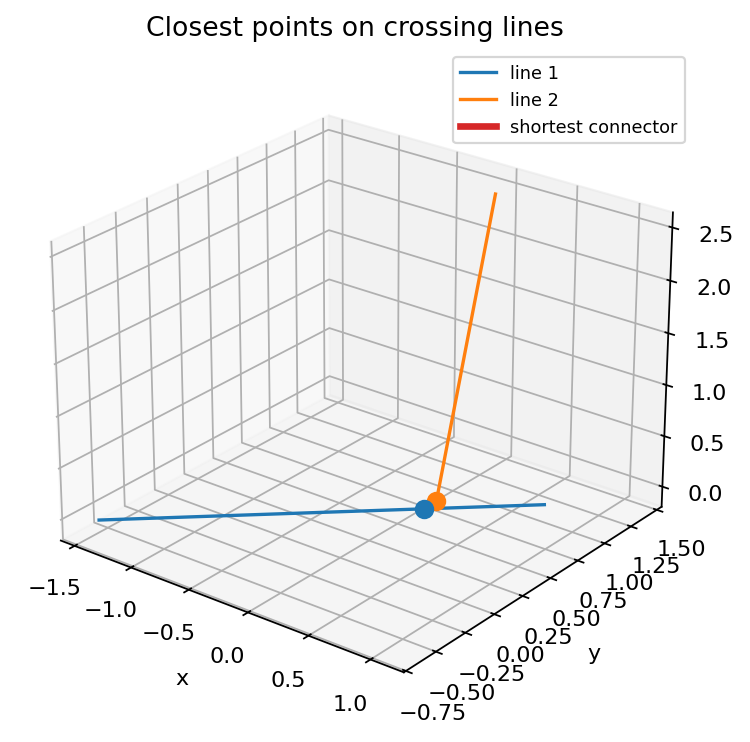

In [17]:
fig = plt.figure(figsize=(7, 5.5))
ax = fig.add_subplot(111, projection="3d")
base1 = np.array([-0.6, -0.2, 0.1])
dir1 = np.array([1.4, 0.7, 0.2])
base2 = np.array([0.2, 0.8, 0.9])
dir2 = np.array([-0.2, 0.5, 1.3])
ts = np.linspace(-0.6, 1.2, 40)
pts1 = base1[None, :] + ts[:, None] * dir1[None, :]
pts2 = base2[None, :] + ts[:, None] * dir2[None, :]
ax.plot(pts1[:, 0], pts1[:, 1], pts1[:, 2], color="#1f77b4", label="line 1")
ax.plot(pts2[:, 0], pts2[:, 1], pts2[:, 2], color="#ff7f0e", label="line 2")
p1_close = skew_result["point1"]
p2_close = skew_result["point2"]
ax.scatter(*p1_close, color="#1f77b4", s=60)
ax.scatter(*p2_close, color="#ff7f0e", s=60)
ax.plot([p1_close[0], p2_close[0]], [p1_close[1], p2_close[1]], [p1_close[2], p2_close[2]], color="#d62728", linewidth=3, label="shortest connector")
ax.set_title("Closest points on crossing lines")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend(fontsize=8)
ax.view_init(elev=25, azim=-52)
crossing_fig_path = save_matplotlib(
    fig, ARTIFACT_TOPIC, "figures", "crossing-line-lab.png", root=ARTIFACT_ROOT
)
plt.close(fig)
display_artifact(crossing_fig_path, width=660)


## Final Sanity Checks

The chapter's applications can be summarized as a chain of invariants. Plucker lines must satisfy `d dot m = 0`. Pinhole projections must place a projected point on the ray through the camera center and the world point. Epipolar residuals must vanish for corresponding exact projections. Back-projected image lines must produce ray planes containing the original world line. Multi-camera marker reconstruction must return small residuals when the correspondence is correct. A view matrix must move its own camera center to the local origin. Closest points on skew lines must be joined by a connector perpendicular to both line directions.

Those checks are deliberately heterogeneous. Some are algebraic, some are numerical, and some are convention checks. That is the reality of using the homogeneous model in computer science: the same projective algebra touches symbolic derivations, floating-point optimization, rendering APIs, and vision pipelines. The final code cell gathers the checks into one JSON artifact and raises an error if any essential condition fails.


In [18]:
expected_artifacts = [
    heading_audit_path,
    plucker_path,
    plucker_fig_path,
    combining_path,
    projection_path,
    image_fig_path,
    epipolar_path,
    epipolar_fig_path,
    ray_plane_path,
    ray_plane_fig_path,
    mocap_path,
    mocap_fig_path,
    transform_path,
    transform_fig_path,
    crossing_path,
    crossing_fig_path,
]
checks = {
    "plucker_constraint_small": abs(plucker_report["grassmann_plucker_constraint"]) < 1e-9,
    "plucker_same_line_moment_stable": plucker_report["same_line_moment_delta_norm"] < 1e-9,
    "epipolar_residuals_small": epipolar_report["max_abs_residual"] < 1e-9,
    "ray_plane_line_alignment": ray_plane_report["absolute_direction_alignment_with_original"] > 0.999999,
    "mocap_error_reasonable": mocap_report["max_position_error"] < 0.02,
    "view_matrix_places_camera_at_origin": float(np.linalg.norm(left_center_in_view[:3])) < 1e-9,
    "crossing_connector_orthogonal": abs(crossing_report["skew"]["connector_dot_d1"]) < 1e-9 and abs(crossing_report["skew"]["connector_dot_d2"]) < 1e-9,
    "near_parallel_detected": bool(crossing_report["near_parallel"]["parallel"]),
    "artifacts_exist": all(Path(path).exists() for path in expected_artifacts),
}
final_report = {
    "all_checks_passed": all(checks.values()),
    "checks": checks,
    "artifact_count": len(expected_artifacts),
    "artifacts": [str(Path(path).relative_to(BOOK_ROOT)) for path in expected_artifacts],
}
final_path = save_json(
    final_report, ARTIFACT_TOPIC, "checks", "final-sanity-checks.json", root=ARTIFACT_ROOT
)
print(final_report)
print(f"wrote {final_path}")
assert final_report["all_checks_passed"], final_report


{'all_checks_passed': True, 'checks': {'plucker_constraint_small': True, 'plucker_same_line_moment_stable': True, 'epipolar_residuals_small': True, 'ray_plane_line_alignment': True, 'mocap_error_reasonable': True, 'view_matrix_places_camera_at_origin': True, 'crossing_connector_orthogonal': True, 'near_parallel_detected': True, 'artifacts_exist': True}, 'artifact_count': 16, 'artifacts': ['artifacts\\chapter-12\\pdf-probe\\heading-audit.json', 'artifacts\\chapter-12\\checks\\plucker-line-invariants.json', 'artifacts\\chapter-12\\figures\\plucker-direction-moment.png', 'artifacts\\chapter-12\\checks\\line-combination-report.json', 'artifacts\\chapter-12\\camera\\pinhole-observations.json', 'artifacts\\chapter-12\\figures\\pinhole-image-observations.png', 'artifacts\\chapter-12\\checks\\epipolar-constraint.json', 'artifacts\\chapter-12\\figures\\epipolar-lines.png', 'artifacts\\chapter-12\\checks\\ray-planes-from-line-observations.json', 'artifacts\\chapter-12\\figures\\line-ray-planes.p